
# LLM Inference Systems for Interview Prep
## Prefill / Decode Metrics, Continuous Batching, Queue-Aware Routing, Prefix Caching, and Server Observability

This notebook is a **teaching-first, interview-focused walkthrough** of the main ideas behind modern LLM inference systems.

It is designed for:
- LLM inference interviews
- LLM infrastructure interviews
- serving / runtime / platform engineering interviews
- candidates who want **intuition + working code**

## What this notebook covers

By the end, you will have:
1. a clear mental model of **prefill** vs **decode**
2. request-level metrics such as **queue time**, **TTFT**, **TPOT**, and **total latency**
3. a simple simulator for **continuous batching intuition**
4. a comparison between **sequential serving** and **continuous batching**
5. a simple **queue-aware router** over multiple backends
6. a toy **prefix caching** simulation
7. a tiny **/metrics-style observability export**
8. several interview-style exercises with **hints and answers**

## Philosophy

This notebook optimizes for:
- **clarity**
- **systems intuition**
- **metrics thinking**
- **beginner-friendly code**
- **heavy code comments**

It does **not** try to reproduce any production inference engine exactly.
The simulator is intentionally simplified so the important ideas stay visible.



## Why this matters for infra-focused roles

Infra-focused LLM interviews often care less about writing the raw Transformer from scratch and more about questions like:

- Why does **TTFT** get worse when prompts are long?
- Why is **decode** usually scheduled differently from **prefill**?
- Why does **continuous batching** help utilization?
- Why can **queue-aware routing** outperform simple round robin?
- Why does **prefix caching** help some workloads but not others?
- What metrics would you expose on a **/metrics** endpoint?

This notebook is built around those questions.


In [1]:

# ============================================================
# Imports
# ============================================================
# This notebook is mostly a systems simulation notebook, so it
# runs well on CPU and does not require a GPU.
#
# We still keep the code clean and Colab-friendly.
# The focus is:
# - intuition
# - metrics
# - queueing
# - routing
# - observability
# - cache reuse
#
# rather than large-model training or CUDA kernels.

import math
import random
import statistics
from collections import Counter, deque
from dataclasses import dataclass, field
from typing import Deque, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.



## 1. The core metrics and vocabulary

Before building any simulator, get the vocabulary straight.

### Prefill
The prompt-ingestion phase:
- tokenize prompt already happened outside the model
- the server computes hidden states / KV for the prompt
- the request is not yet streaming tokens back to the user

### Decode
The token-generation phase:
- generate one or a few new tokens at a time
- reuse prompt-side KV / cache state
- user-visible streaming typically happens here

### Queue time
How long a request waits before the server starts prefill.

### TTFT (time to first token)
How long from request arrival until the first generated token appears.

### TPOT (time per output token)
A simplified "decode speed" view:
- after the first token arrives
- how quickly do later tokens appear?

### Total latency
Arrival to completion.

### Prompt token throughput
How many prompt tokens the backend processes per second.

### Generation token throughput
How many output tokens the backend generates per second.

### Prefix caching
Reuse prompt-side work for repeated prefixes so later requests can skip some prefill.

### Observability
Expose metrics and traces so humans and automation can answer:
- what is waiting?
- what is running?
- what is slow?
- what is overloaded?
- where is the throughput going?


In [2]:

# ============================================================
# Core request and simulator data structures
# ============================================================
# The goal is to build a small, readable simulator that captures
# the *important ideas* behind modern LLM inference systems:
#
# - prefill vs decode
# - TTFT / TPOT / total latency
# - continuous batching intuition
# - queueing and routing
# - prefix caching
# - metrics and observability
#
# Important note:
# This is NOT a production scheduler and NOT a replica of vLLM.
# It is a teaching simulator that uses the same conceptual ideas.

@dataclass
class InferenceRequest:
    # A user-facing request entering the server.
    request_id: str

    # When the request arrives at the server, in simulated milliseconds.
    arrival_ms: int

    # Number of prompt tokens that must be ingested during prefill.
    prompt_tokens: int

    # Number of output tokens the request wants to generate.
    output_tokens: int

    # Optional prefix-cache key.
    # If two requests share the same prefix key, they may be able to
    # reuse cached prompt work.
    prefix_key: Optional[str] = None

    # Number of prompt tokens that are eligible for reuse if the prefix
    # is already cached. This can be smaller than the full prompt.
    cacheable_tokens: int = 0


@dataclass
class RuntimeRequest:
    # Runtime state derived from an InferenceRequest.
    request_id: str
    arrival_ms: int
    prompt_tokens: int
    output_tokens: int
    prefix_key: Optional[str] = None
    cacheable_tokens: int = 0

    # How many prompt tokens are *actually* left to compute after
    # considering prefix-cache reuse.
    effective_prompt_tokens: int = 0
    remaining_prompt_tokens: int = 0

    # How many output tokens still need to be generated.
    remaining_output_tokens: int = 0

    # waiting -> prefill -> decode -> done
    state: str = "waiting"

    # Whether this request reused cached prefix work.
    used_prefix_cache: bool = False

    # Which backend handled the request.
    route: Optional[str] = None

    # Timestamps for latency metrics.
    queue_enter_ms: int = 0
    start_prefill_ms: Optional[int] = None
    first_token_ms: Optional[int] = None
    finish_ms: Optional[int] = None

    # Accounting counters.
    prompt_tokens_computed: int = 0
    output_tokens_computed: int = 0


@dataclass
class EngineConfig:
    # Simulation time step size.
    step_ms: int = 10

    # Total token budget the backend can process per step.
    # Think of this as a simplified throughput budget.
    token_budget_per_step: int = 16

    # Upper bound on how many prompt tokens a single waiting request
    # can consume in one step before we rotate fairness to others.
    max_prefill_chunk_per_request: int = 8

    # Whether prefix caching is enabled.
    enable_prefix_cache: bool = False


def clone_into_runtime(req: InferenceRequest) -> RuntimeRequest:
    """Convert a static request into a mutable runtime request."""
    return RuntimeRequest(
        request_id=req.request_id,
        arrival_ms=req.arrival_ms,
        prompt_tokens=req.prompt_tokens,
        output_tokens=req.output_tokens,
        prefix_key=req.prefix_key,
        cacheable_tokens=req.cacheable_tokens,
        effective_prompt_tokens=req.prompt_tokens,
        remaining_prompt_tokens=req.prompt_tokens,
        remaining_output_tokens=req.output_tokens,
        queue_enter_ms=req.arrival_ms,
    )


def percentile(values: List[float], pct: float) -> float:
    """Simple linear percentile helper for small demo tables."""
    if not values:
        return float("nan")

    sorted_values = sorted(values)

    # Convert percentile to a zero-based index position.
    position = (len(sorted_values) - 1) * pct

    lower = int(math.floor(position))
    upper = int(math.ceil(position))

    if lower == upper:
        return float(sorted_values[lower])

    weight = position - lower
    return float(sorted_values[lower] * (1.0 - weight) + sorted_values[upper] * weight)


def summarize_completed_requests(completed: List[RuntimeRequest]) -> List[Dict[str, float]]:
    """
    Turn finished runtime requests into a per-request metric table.
    """
    rows: List[Dict[str, float]] = []

    for req in completed:
        # Time to first token:
        # from arrival to the first generated token.
        ttft_ms = float(req.first_token_ms - req.arrival_ms)

        # Total latency:
        # from arrival to final completion.
        total_latency_ms = float(req.finish_ms - req.arrival_ms)

        # Queue time:
        # how long the request waited before prefill started.
        queue_time_ms = float(req.start_prefill_ms - req.arrival_ms)

        # Time per output token after the first token.
        # This is a simplified TPOT-style metric.
        if req.output_tokens > 1:
            tpot_ms = float(req.finish_ms - req.first_token_ms) / float(req.output_tokens - 1)
        else:
            tpot_ms = 0.0

        rows.append(
            {
                "request_id": req.request_id,
                "route": req.route or "",
                "prompt_tokens": float(req.prompt_tokens),
                "effective_prompt_tokens": float(req.effective_prompt_tokens),
                "output_tokens": float(req.output_tokens),
                "queue_time_ms": queue_time_ms,
                "ttft_ms": ttft_ms,
                "tpot_ms": tpot_ms,
                "total_latency_ms": total_latency_ms,
                "used_prefix_cache": 1.0 if req.used_prefix_cache else 0.0,
            }
        )

    return rows


def summarize_run(
    completed: List[RuntimeRequest],
    history: List[Dict[str, float]],
    total_prompt_tokens_computed: int,
    total_output_tokens_computed: int,
    total_cacheable_tokens_requested: int,
    total_cached_tokens_reused: int,
) -> Dict[str, object]:
    """
    Build an aggregate summary for one backend or one single-backend run.
    """
    rows = summarize_completed_requests(completed)

    ttfts = [row["ttft_ms"] for row in rows]
    totals = [row["total_latency_ms"] for row in rows]
    queues = [row["queue_time_ms"] for row in rows]
    tpots = [row["tpot_ms"] for row in rows]

    makespan_ms = float(history[-1]["time_ms"]) if history else 0.0
    seconds = makespan_ms / 1000.0 if makespan_ms > 0 else 1.0

    return {
        "num_requests": len(rows),
        "makespan_ms": makespan_ms,
        "avg_queue_time_ms": statistics.mean(queues) if queues else float("nan"),
        "avg_ttft_ms": statistics.mean(ttfts) if ttfts else float("nan"),
        "p95_ttft_ms": percentile(ttfts, 0.95),
        "avg_tpot_ms": statistics.mean(tpots) if tpots else float("nan"),
        "avg_total_latency_ms": statistics.mean(totals) if totals else float("nan"),
        "p95_total_latency_ms": percentile(totals, 0.95),
        "prompt_tokens_per_s": total_prompt_tokens_computed / seconds,
        "output_tokens_per_s": total_output_tokens_computed / seconds,
        "prefix_cache_hit_rate": (
            total_cached_tokens_reused / total_cacheable_tokens_requested
            if total_cacheable_tokens_requested > 0
            else 0.0
        ),
        "rows": rows,
    }


class SequentialServer:
    """
    A very simple baseline server:
    - one request at a time
    - no overlap between requests
    - useful as a contrast against continuous batching
    """

    def __init__(self, config: EngineConfig):
        self.config = config

        self.total_prompt_tokens_computed = 0
        self.total_output_tokens_computed = 0

        self.total_cacheable_tokens_requested = 0
        self.total_cached_tokens_reused = 0
        self.prefix_cache: Dict[str, int] = {}

    def run(self, requests: List[InferenceRequest]) -> Tuple[List[RuntimeRequest], List[Dict[str, float]]]:
        completed: List[RuntimeRequest] = []
        history: List[Dict[str, float]] = []

        # The server is free at time 0.
        server_free_ms = 0

        for req in sorted(requests, key=lambda r: r.arrival_ms):
            rt = clone_into_runtime(req)
            rt.route = "sequential"

            # Apply prefix-cache reuse if enabled and available.
            if self.config.enable_prefix_cache and req.prefix_key is not None and req.cacheable_tokens > 0:
                requested_cacheable = min(req.cacheable_tokens, req.prompt_tokens)
                self.total_cacheable_tokens_requested += requested_cacheable

                reusable = min(
                    self.prefix_cache.get(req.prefix_key, 0),
                    req.cacheable_tokens,
                    req.prompt_tokens,
                )

                if reusable > 0:
                    rt.used_prefix_cache = True
                    rt.effective_prompt_tokens = req.prompt_tokens - reusable
                    rt.remaining_prompt_tokens = rt.effective_prompt_tokens
                    self.total_cached_tokens_reused += reusable

            # The request can only start once:
            # - it has arrived
            # - the single server is free
            start_prefill_ms = max(req.arrival_ms, server_free_ms)
            rt.start_prefill_ms = start_prefill_ms

            # Prefill consumes prompt work before first token appears.
            prefill_steps = math.ceil(rt.remaining_prompt_tokens / self.config.token_budget_per_step)

            # We model first token as appearing one step after the prompt has
            # been fully ingested and decoding begins.
            rt.first_token_ms = start_prefill_ms + prefill_steps * self.config.step_ms + self.config.step_ms

            # Remaining decode tokens each cost one step in this simplified model.
            rt.finish_ms = rt.first_token_ms + (rt.output_tokens - 1) * self.config.step_ms

            # Update server availability.
            server_free_ms = rt.finish_ms

            # Update accounting.
            rt.prompt_tokens_computed = rt.effective_prompt_tokens
            rt.output_tokens_computed = rt.output_tokens
            rt.state = "done"

            self.total_prompt_tokens_computed += rt.prompt_tokens_computed
            self.total_output_tokens_computed += rt.output_tokens_computed

            # Once a prompt has been computed, it can seed the prefix cache.
            if self.config.enable_prefix_cache and req.prefix_key is not None and req.cacheable_tokens > 0:
                self.prefix_cache[req.prefix_key] = max(
                    self.prefix_cache.get(req.prefix_key, 0),
                    min(req.prompt_tokens, req.cacheable_tokens),
                )

            completed.append(rt)

        history.append(
            {
                "time_ms": float(server_free_ms),
                "waiting_requests": 0.0,
                "decoding_requests": 0.0,
                "queue_depth": 0.0,
                "prompt_tokens_processed": float(self.total_prompt_tokens_computed),
                "output_tokens_processed": float(self.total_output_tokens_computed),
                "prefix_cache_hit_rate": (
                    self.total_cached_tokens_reused / self.total_cacheable_tokens_requested
                    if self.total_cacheable_tokens_requested > 0
                    else 0.0
                ),
                "cache_entries": float(len(self.prefix_cache)),
            }
        )

        return completed, history


class ContinuousBatchingSimulator:
    """
    A teaching-oriented simulator for continuous batching intuition.

    It models a backend that, at every time step:
    1) gives one decode token to as many active decoding requests as budget allows
    2) uses the remaining token budget for prefill work on waiting requests

    This captures a very important serving intuition:
    - decode work is latency-sensitive because it unblocks token streaming
    - prefill can be chunked and interleaved with decode work
    """

    def __init__(self, config: EngineConfig, name: str = "backend"):
        self.config = config
        self.name = name

        # Waiting requests have not yet finished prefill.
        self.waiting: Deque[RuntimeRequest] = deque()

        # Decoding requests have finished prefill and are now producing tokens.
        self.decoding: Deque[RuntimeRequest] = deque()

        # Completed requests are stored for later metric computation.
        self.completed: List[RuntimeRequest] = []

        # Simple prefix-cache state:
        # maps prefix_key -> reusable token count
        self.prefix_cache: Dict[str, int] = {}

        # Aggregate counters for reporting.
        self.total_prompt_tokens_computed = 0
        self.total_output_tokens_computed = 0

        self.total_cacheable_tokens_requested = 0
        self.total_cached_tokens_reused = 0

        # Per-step observability history.
        self.history: List[Dict[str, float]] = []

    def pending_requests(self) -> int:
        """How many requests are still in the system?"""
        return len(self.waiting) + len(self.decoding)

    def remaining_prefill_tokens(self) -> int:
        """Useful as a lightweight load signal for routing."""
        return sum(req.remaining_prompt_tokens for req in self.waiting)

    def load_score(self) -> float:
        """
        A simple queue-aware routing score.

        Lower is better.
        We mix:
        - number of waiting requests
        - number of decoding requests
        - amount of prompt work still queued
        """
        return (
            len(self.waiting)
            + len(self.decoding)
            + 0.02 * self.remaining_prefill_tokens()
        )

    def add_request(self, req: InferenceRequest) -> None:
        """
        Admit a new request into the backend's waiting queue.
        """
        rt = clone_into_runtime(req)
        rt.route = self.name

        # Prefix-cache reuse happens when the same prefix has already been
        # computed for an earlier request.
        if self.config.enable_prefix_cache and req.prefix_key is not None and req.cacheable_tokens > 0:
            requested_cacheable = min(req.cacheable_tokens, req.prompt_tokens)
            self.total_cacheable_tokens_requested += requested_cacheable

            reusable = min(
                self.prefix_cache.get(req.prefix_key, 0),
                req.cacheable_tokens,
                req.prompt_tokens,
            )

            if reusable > 0:
                rt.used_prefix_cache = True
                rt.effective_prompt_tokens = req.prompt_tokens - reusable
                rt.remaining_prompt_tokens = rt.effective_prompt_tokens
                self.total_cached_tokens_reused += reusable

        self.waiting.append(rt)

    def step(self, now_ms: int) -> None:
        """
        Process one scheduler step.

        This is the core teaching loop for the backend.
        """
        budget = self.config.token_budget_per_step

        prompt_tokens_this_step = 0
        output_tokens_this_step = 0

        # ----------------------------------------------------
        # Phase 1: decode work
        # ----------------------------------------------------
        # We prioritize decode because:
        # - it advances streaming outputs
        # - it improves user-visible responsiveness
        #
        # We give at most one token to each active decoding request
        # per scheduler step, in round-robin order.
        decode_count = len(self.decoding)
        for _ in range(decode_count):
            if budget <= 0:
                break

            req = self.decoding.popleft()

            # The first time this request gets a decode token, that is its TTFT.
            if req.first_token_ms is None:
                req.first_token_ms = now_ms + self.config.step_ms

            req.remaining_output_tokens -= 1
            req.output_tokens_computed += 1

            output_tokens_this_step += 1
            budget -= 1

            if req.remaining_output_tokens <= 0:
                req.finish_ms = now_ms + self.config.step_ms
                req.state = "done"
                self.completed.append(req)
            else:
                self.decoding.append(req)

        # ----------------------------------------------------
        # Phase 2: prefill work
        # ----------------------------------------------------
        # We use the remaining budget for prompt ingestion.
        #
        # To keep the scheduler more fair and intuitive, we chunk prefill
        # per request and rotate unfinished requests to the back of the queue.
        waiting_count = len(self.waiting)
        processed_waiting_requests = 0

        while budget > 0 and self.waiting and processed_waiting_requests < waiting_count:
            req = self.waiting.popleft()

            if req.start_prefill_ms is None:
                req.start_prefill_ms = now_ms

            req.state = "prefill"

            chunk = min(
                budget,
                self.config.max_prefill_chunk_per_request,
                req.remaining_prompt_tokens,
            )

            req.remaining_prompt_tokens -= chunk
            req.prompt_tokens_computed += chunk

            prompt_tokens_this_step += chunk
            budget -= chunk

            if req.remaining_prompt_tokens <= 0:
                req.state = "decode"

                # Once the prompt is computed, its cacheable prefix becomes
                # available for later requests.
                if self.config.enable_prefix_cache and req.prefix_key is not None and req.cacheable_tokens > 0:
                    self.prefix_cache[req.prefix_key] = max(
                        self.prefix_cache.get(req.prefix_key, 0),
                        min(req.prompt_tokens, req.cacheable_tokens),
                    )

                self.decoding.append(req)
            else:
                # Still needs more prompt work later.
                req.state = "waiting"
                self.waiting.append(req)

            processed_waiting_requests += 1

        self.total_prompt_tokens_computed += prompt_tokens_this_step
        self.total_output_tokens_computed += output_tokens_this_step

        self.history.append(
            {
                "time_ms": float(now_ms + self.config.step_ms),
                "waiting_requests": float(len(self.waiting)),
                "decoding_requests": float(len(self.decoding)),
                "queue_depth": float(len(self.waiting) + len(self.decoding)),
                "prompt_tokens_processed": float(prompt_tokens_this_step),
                "output_tokens_processed": float(output_tokens_this_step),
                "prefix_cache_hit_rate": (
                    self.total_cached_tokens_reused / self.total_cacheable_tokens_requested
                    if self.total_cacheable_tokens_requested > 0
                    else 0.0
                ),
                "cache_entries": float(len(self.prefix_cache)),
            }
        )

    def run(self, requests: List[InferenceRequest], max_steps: int = 10000) -> Tuple[List[RuntimeRequest], List[Dict[str, float]]]:
        """
        Run until all requests finish.
        """
        requests_sorted = sorted(requests, key=lambda r: r.arrival_ms)

        arrival_index = 0
        now_ms = 0
        steps = 0

        while arrival_index < len(requests_sorted) or self.pending_requests() > 0:
            # Admit all requests that have arrived by this time step.
            while arrival_index < len(requests_sorted) and requests_sorted[arrival_index].arrival_ms <= now_ms:
                self.add_request(requests_sorted[arrival_index])
                arrival_index += 1

            # Advance the backend by one scheduler step.
            self.step(now_ms)

            now_ms += self.config.step_ms
            steps += 1

            if steps > max_steps:
                raise RuntimeError("Simulation exceeded max_steps; check scheduler logic.")

        return self.completed, self.history


def export_metrics_text(simulator: ContinuousBatchingSimulator) -> str:
    """
    Export a tiny Prometheus-like text snapshot.

    This is not a full Prometheus exposition format.
    It is just enough to teach the idea of a /metrics endpoint.
    """
    if not simulator.history:
        return ""

    latest = simulator.history[-1]

    lines = [
        f"inference_waiting_requests {latest['waiting_requests']}",
        f"inference_decoding_requests {latest['decoding_requests']}",
        f"inference_queue_depth {latest['queue_depth']}",
        f"inference_prompt_tokens_total {simulator.total_prompt_tokens_computed}",
        f"inference_output_tokens_total {simulator.total_output_tokens_computed}",
        f"inference_prefix_cache_hit_rate {latest['prefix_cache_hit_rate']:.6f}",
        f"inference_cache_entries {latest['cache_entries']}",
    ]
    return "\n".join(lines)


def parse_metrics_text(metrics_text: str) -> Dict[str, float]:
    """
    Parse the tiny exposition string back into a dictionary.
    """
    result: Dict[str, float] = {}
    for line in metrics_text.strip().splitlines():
        if not line.strip():
            continue
        name, value = line.split()
        result[name] = float(value)
    return result


# ------------------------------------------------------------
# Workload generators
# ------------------------------------------------------------
# These workloads are deterministic so the notebook stays stable.

def make_mixed_workload(seed: int = 7, num_requests: int = 12) -> List[InferenceRequest]:
    """
    Mixed prompts + bursty arrivals.
    Good for sequential vs continuous-batching comparisons.
    """
    random.seed(seed)

    requests: List[InferenceRequest] = []
    current_arrival = 0

    for idx in range(num_requests):
        # A few bursts and a few gaps.
        if idx in {0, 1, 2, 6, 7}:
            current_arrival += 0
        else:
            current_arrival += random.choice([10, 10, 20])

        prompt_tokens = random.choice([8, 12, 16, 24, 32])
        output_tokens = random.choice([6, 8, 10])

        requests.append(
            InferenceRequest(
                request_id=f"req_{idx}",
                arrival_ms=current_arrival,
                prompt_tokens=prompt_tokens,
                output_tokens=output_tokens,
            )
        )

    return requests


def make_prefix_heavy_workload() -> List[InferenceRequest]:
    """
    A prefix-heavy workload where later requests can strongly benefit
    from prefix caching.
    """
    arrivals = [0, 40, 50, 60, 70, 80, 0, 50, 60, 70]
    keys = ["A", "A", "A", "A", "A", "A", "B", "B", "B", "B"]

    requests: List[InferenceRequest] = []
    for idx, (arrival_ms, key) in enumerate(zip(arrivals, keys)):
        requests.append(
            InferenceRequest(
                request_id=f"prefix_{idx}",
                arrival_ms=arrival_ms,
                prompt_tokens=40,
                output_tokens=8,
                prefix_key=key,
                cacheable_tokens=32,
            )
        )
    return requests


def make_bursty_routing_workload(seed: int = 11, num_requests: int = 18) -> List[InferenceRequest]:
    """
    A burst-heavy workload for routing comparisons.
    """
    random.seed(seed)

    fixed_arrivals = [0, 0, 0, 10, 10, 20, 40, 40, 40, 50, 70, 70, 90, 90, 110, 120, 120, 140]

    requests: List[InferenceRequest] = []
    for idx in range(num_requests):
        requests.append(
            InferenceRequest(
                request_id=f"route_{idx}",
                arrival_ms=fixed_arrivals[idx],
                prompt_tokens=random.choice([8, 12, 16, 32, 40]),
                output_tokens=random.choice([8, 10, 12]),
            )
        )
    return requests



## 2. Sequential serving baseline

We start with the simplest possible baseline:
- one request at a time
- no overlap
- the next request waits until the previous request fully finishes

This is *not* how modern high-throughput inference engines usually behave, but it is a great baseline because it makes the value of continuous batching obvious.



## 3. Continuous batching intuition

A continuous-batching engine tries to keep the device busy across multiple requests.

### Simplified intuition used in this notebook
At every scheduler step:
1. give decode work to already-running requests first
2. use leftover budget for prompt prefill work
3. rotate unfinished waiting requests so long prompts do not monopolize all progress forever

This is a simplified model, but it captures several real-serving ideas:
- decode is latency-sensitive
- prefill is often heavy
- batching decisions affect both utilization and user-visible latency


Sequential summary
       avg_queue_time_ms: 442.50
             avg_ttft_ms: 467.50
             p95_ttft_ms: 857.00
    avg_total_latency_ms: 530.83
             makespan_ms: 1060.00
     prompt_tokens_per_s: 218.87
     output_tokens_per_s: 83.02

Continuous batching summary
       avg_queue_time_ms: 5.83
             avg_ttft_ms: 63.33
             p95_ttft_ms: 120.00
    avg_total_latency_ms: 126.67
             makespan_ms: 270.00
     prompt_tokens_per_s: 859.26
     output_tokens_per_s: 325.93


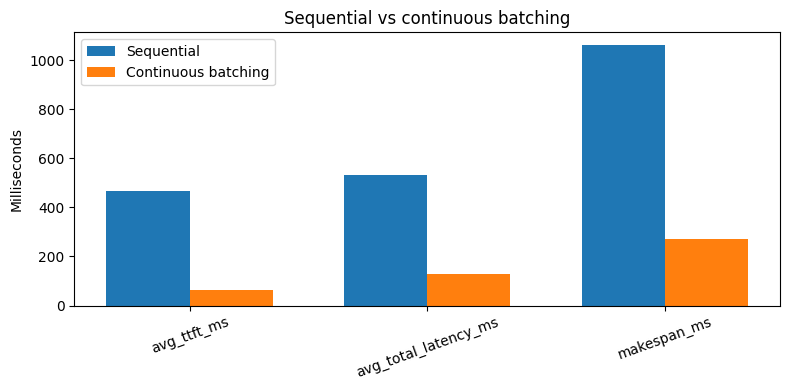

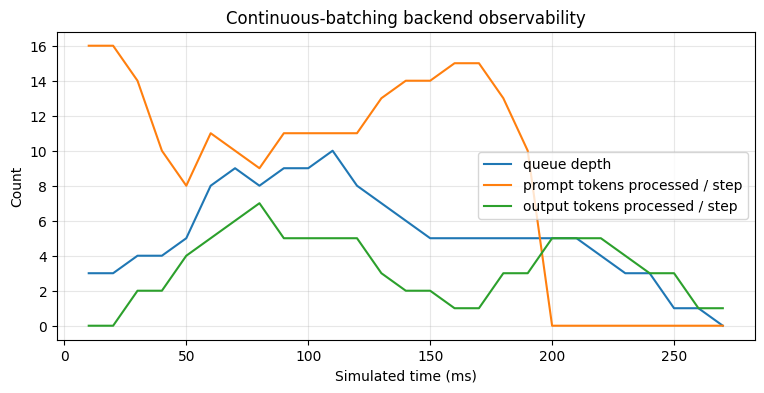

In [3]:

# ============================================================
# Sequential vs continuous batching demo
# ============================================================

# Build one mixed workload with bursts and different prompt lengths.
mixed_requests = make_mixed_workload(seed=7, num_requests=12)

# A small token budget is enough to make scheduling tradeoffs visible.
demo_config = EngineConfig(
    step_ms=10,
    token_budget_per_step=16,
    max_prefill_chunk_per_request=8,
    enable_prefix_cache=False,
)

# ----- Sequential baseline -----
sequential_server = SequentialServer(demo_config)
seq_completed, seq_history = sequential_server.run(mixed_requests)
seq_summary = summarize_run(
    completed=seq_completed,
    history=seq_history,
    total_prompt_tokens_computed=sequential_server.total_prompt_tokens_computed,
    total_output_tokens_computed=sequential_server.total_output_tokens_computed,
    total_cacheable_tokens_requested=sequential_server.total_cacheable_tokens_requested,
    total_cached_tokens_reused=sequential_server.total_cached_tokens_reused,
)

# ----- Continuous batching -----
continuous_server = ContinuousBatchingSimulator(demo_config, name="cb_backend")
cb_completed, cb_history = continuous_server.run(mixed_requests)
cb_summary = summarize_run(
    completed=cb_completed,
    history=cb_history,
    total_prompt_tokens_computed=continuous_server.total_prompt_tokens_computed,
    total_output_tokens_computed=continuous_server.total_output_tokens_computed,
    total_cacheable_tokens_requested=continuous_server.total_cacheable_tokens_requested,
    total_cached_tokens_reused=continuous_server.total_cached_tokens_reused,
)

print("Sequential summary")
for key in ["avg_queue_time_ms", "avg_ttft_ms", "p95_ttft_ms", "avg_total_latency_ms", "makespan_ms", "prompt_tokens_per_s", "output_tokens_per_s"]:
    print(f"  {key:>22}: {seq_summary[key]:.2f}")

print("\nContinuous batching summary")
for key in ["avg_queue_time_ms", "avg_ttft_ms", "p95_ttft_ms", "avg_total_latency_ms", "makespan_ms", "prompt_tokens_per_s", "output_tokens_per_s"]:
    print(f"  {key:>22}: {cb_summary[key]:.2f}")

# Plot a few headline metrics side by side.
metric_names = ["avg_ttft_ms", "avg_total_latency_ms", "makespan_ms"]
seq_values = [seq_summary[name] for name in metric_names]
cb_values = [cb_summary[name] for name in metric_names]

x_positions = range(len(metric_names))
bar_width = 0.35

plt.figure(figsize=(8, 4))
plt.bar([x - bar_width / 2 for x in x_positions], seq_values, width=bar_width, label="Sequential")
plt.bar([x + bar_width / 2 for x in x_positions], cb_values, width=bar_width, label="Continuous batching")
plt.xticks(list(x_positions), metric_names, rotation=20)
plt.ylabel("Milliseconds")
plt.title("Sequential vs continuous batching")
plt.legend()
plt.tight_layout()
plt.show()

# Plot continuous-batching observability over time.
times = [entry["time_ms"] for entry in cb_history]
queue_depths = [entry["queue_depth"] for entry in cb_history]
prompt_rates = [entry["prompt_tokens_processed"] for entry in cb_history]
decode_rates = [entry["output_tokens_processed"] for entry in cb_history]

plt.figure(figsize=(9, 4))
plt.plot(times, queue_depths, label="queue depth")
plt.plot(times, prompt_rates, label="prompt tokens processed / step")
plt.plot(times, decode_rates, label="output tokens processed / step")
plt.xlabel("Simulated time (ms)")
plt.ylabel("Count")
plt.title("Continuous-batching backend observability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



### What to notice

In this toy simulator, continuous batching usually improves:
- average TTFT
- overall makespan
- throughput

Why?
Because the backend is not forced to finish one full request before touching the next one.

But it can also create tradeoffs:
- some requests may wait longer in the tail
- very large prompts can still create pressure
- scheduling policy matters



## 4. Prefix caching intuition

Prefix caching is about skipping repeated prompt work.

### Mental model
If request B shares a long prefix with request A, then after request A's prefix is already in cache:
- request B can reuse part of the prompt-side work
- B's **effective prefill cost** becomes smaller
- B's TTFT can improve

### Very important interview point
Prefix caching does **not** change the model's answer.
It changes **how much prefill work has to be recomputed**.


No-cache summary
             avg_ttft_ms: 170.00
    avg_total_latency_ms: 240.00
     prompt_tokens_per_s: 1111.11
     output_tokens_per_s: 222.22
   prefix_cache_hit_rate: 0.00

Prefix-cache summary
             avg_ttft_ms: 54.00
    avg_total_latency_ms: 124.00
     prompt_tokens_per_s: 800.00
     output_tokens_per_s: 363.64
   prefix_cache_hit_rate: 0.70

Prompt tokens actually computed
  without cache: 400
  with cache:    176


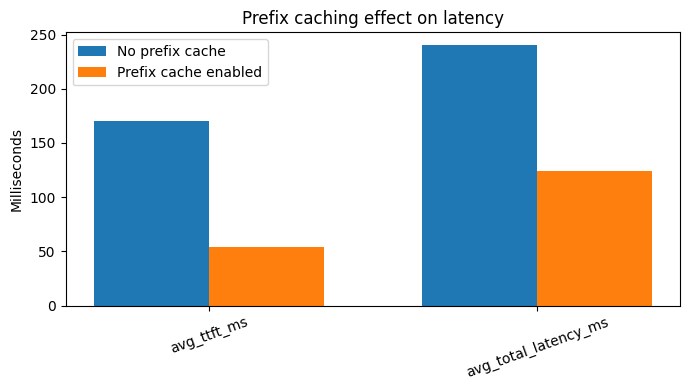

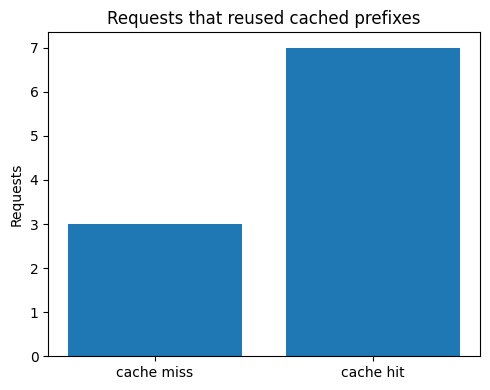

In [4]:

# ============================================================
# Prefix caching demo
# ============================================================

prefix_requests = make_prefix_heavy_workload()

# Run once with no prefix cache.
no_cache_server = ContinuousBatchingSimulator(
    EngineConfig(
        step_ms=10,
        token_budget_per_step=16,
        max_prefill_chunk_per_request=8,
        enable_prefix_cache=False,
    ),
    name="no_cache_backend",
)
no_cache_completed, no_cache_history = no_cache_server.run(prefix_requests)
no_cache_summary = summarize_run(
    completed=no_cache_completed,
    history=no_cache_history,
    total_prompt_tokens_computed=no_cache_server.total_prompt_tokens_computed,
    total_output_tokens_computed=no_cache_server.total_output_tokens_computed,
    total_cacheable_tokens_requested=no_cache_server.total_cacheable_tokens_requested,
    total_cached_tokens_reused=no_cache_server.total_cached_tokens_reused,
)

# Run again with prefix cache enabled.
cache_server = ContinuousBatchingSimulator(
    EngineConfig(
        step_ms=10,
        token_budget_per_step=16,
        max_prefill_chunk_per_request=8,
        enable_prefix_cache=True,
    ),
    name="cache_backend",
)
cache_completed, cache_history = cache_server.run(prefix_requests)
cache_summary = summarize_run(
    completed=cache_completed,
    history=cache_history,
    total_prompt_tokens_computed=cache_server.total_prompt_tokens_computed,
    total_output_tokens_computed=cache_server.total_output_tokens_computed,
    total_cacheable_tokens_requested=cache_server.total_cacheable_tokens_requested,
    total_cached_tokens_reused=cache_server.total_cached_tokens_reused,
)

print("No-cache summary")
for key in ["avg_ttft_ms", "avg_total_latency_ms", "prompt_tokens_per_s", "output_tokens_per_s", "prefix_cache_hit_rate"]:
    print(f"  {key:>22}: {no_cache_summary[key]:.2f}")

print("\nPrefix-cache summary")
for key in ["avg_ttft_ms", "avg_total_latency_ms", "prompt_tokens_per_s", "output_tokens_per_s", "prefix_cache_hit_rate"]:
    print(f"  {key:>22}: {cache_summary[key]:.2f}")

print("\nPrompt tokens actually computed")
print(f"  without cache: {no_cache_server.total_prompt_tokens_computed}")
print(f"  with cache:    {cache_server.total_prompt_tokens_computed}")

# Compare headline metrics visually.
metric_names = ["avg_ttft_ms", "avg_total_latency_ms"]
no_cache_values = [no_cache_summary[name] for name in metric_names]
cache_values = [cache_summary[name] for name in metric_names]

x_positions = range(len(metric_names))
bar_width = 0.35

plt.figure(figsize=(7, 4))
plt.bar([x - bar_width / 2 for x in x_positions], no_cache_values, width=bar_width, label="No prefix cache")
plt.bar([x + bar_width / 2 for x in x_positions], cache_values, width=bar_width, label="Prefix cache enabled")
plt.xticks(list(x_positions), metric_names, rotation=20)
plt.ylabel("Milliseconds")
plt.title("Prefix caching effect on latency")
plt.legend()
plt.tight_layout()
plt.show()

# Show how many requests used the cache.
used_cache_count = sum(int(req.used_prefix_cache) for req in cache_completed)
unused_cache_count = len(cache_completed) - used_cache_count

plt.figure(figsize=(5, 4))
plt.bar(["cache miss", "cache hit"], [unused_cache_count, used_cache_count])
plt.ylabel("Requests")
plt.title("Requests that reused cached prefixes")
plt.tight_layout()
plt.show()



### What to notice

A prefix-heavy workload usually shows:
- fewer prompt tokens recomputed
- lower average TTFT
- sometimes lower total latency
- non-zero prefix-cache hit rate

But cache usefulness is workload-dependent:
- if prompts are mostly unique, prefix caching helps less
- if many requests share templates or system prompts, it can help a lot



## 5. Queue-aware routing intuition

Now move one layer up: **multiple backends**.

A front-end router often has to decide:
- which backend should take this request?
- should we use simple round robin?
- should we prefer the backend with the shorter queue?
- should we avoid a slow or overloaded backend?

### Two policies in this notebook
1. **Round robin**  
   Alternate backends without looking at load.
2. **Queue aware**  
   Route to the backend with the lower current load score.

### Important interview idea
Round robin is simple and often okay when backends are equal and healthy.

Queue-aware routing helps more when:
- one backend is slower
- one backend is already backed up
- workloads are bursty and uneven


In [5]:

# ============================================================
# Queue-aware routing over multiple backends
# ============================================================
# This is a *cluster-level* simulator.
#
# A request arrives at the router first.
# The router chooses a backend.
# Each backend then runs its own local scheduler.
#
# We compare:
# - round robin
# - queue-aware routing

class ClusterRouterSimulator:
    def __init__(self, backends: List[ContinuousBatchingSimulator], policy: str = "round_robin"):
        self.backends = backends
        self.policy = policy
        self.round_robin_index = 0
        self.route_log: List[Dict[str, object]] = []

    def choose_backend(self, req: InferenceRequest) -> ContinuousBatchingSimulator:
        """
        Choose a backend according to the routing policy.
        """
        if self.policy == "round_robin":
            backend = self.backends[self.round_robin_index % len(self.backends)]
            self.round_robin_index += 1
            return backend

        if self.policy == "queue_aware":
            # Lower score means less loaded.
            return min(self.backends, key=lambda backend: backend.load_score())

        raise ValueError(f"Unknown policy: {self.policy}")

    def run(self, requests: List[InferenceRequest], max_steps: int = 10000) -> Tuple[List[RuntimeRequest], Dict[str, List[Dict[str, float]]]]:
        requests_sorted = sorted(requests, key=lambda r: r.arrival_ms)

        arrival_index = 0
        now_ms = 0
        steps = 0

        while arrival_index < len(requests_sorted) or any(backend.pending_requests() > 0 for backend in self.backends):
            # Route all arrivals visible at this time step.
            while arrival_index < len(requests_sorted) and requests_sorted[arrival_index].arrival_ms <= now_ms:
                req = requests_sorted[arrival_index]
                backend = self.choose_backend(req)
                backend.add_request(req)

                self.route_log.append(
                    {
                        "request_id": req.request_id,
                        "time_ms": now_ms,
                        "backend": backend.name,
                        "policy": self.policy,
                    }
                )

                arrival_index += 1

            # Advance every backend by one scheduler tick.
            for backend in self.backends:
                backend.step(now_ms)

            now_ms += self.backends[0].config.step_ms
            steps += 1

            if steps > max_steps:
                raise RuntimeError("Cluster simulation exceeded max_steps; check routing or scheduler logic.")

        all_completed: List[RuntimeRequest] = []
        all_history: Dict[str, List[Dict[str, float]]] = {}

        for backend in self.backends:
            all_completed.extend(backend.completed)
            all_history[backend.name] = backend.history

        return all_completed, all_history


def summarize_cluster_run(
    completed: List[RuntimeRequest],
    history_by_backend: Dict[str, List[Dict[str, float]]],
    backends: List[ContinuousBatchingSimulator],
) -> Dict[str, object]:
    """
    Aggregate metrics across the cluster.
    """
    rows = summarize_completed_requests(completed)

    ttfts = [row["ttft_ms"] for row in rows]
    totals = [row["total_latency_ms"] for row in rows]

    makespan_ms = max((history[-1]["time_ms"] if history else 0.0) for history in history_by_backend.values())
    seconds = makespan_ms / 1000.0 if makespan_ms > 0 else 1.0

    total_prompt = sum(backend.total_prompt_tokens_computed for backend in backends)
    total_output = sum(backend.total_output_tokens_computed for backend in backends)

    route_counts = Counter(row["route"] for row in rows)

    return {
        "num_requests": len(rows),
        "makespan_ms": makespan_ms,
        "avg_ttft_ms": statistics.mean(ttfts) if ttfts else float("nan"),
        "avg_total_latency_ms": statistics.mean(totals) if totals else float("nan"),
        "p95_ttft_ms": percentile(ttfts, 0.95),
        "p95_total_latency_ms": percentile(totals, 0.95),
        "prompt_tokens_per_s": total_prompt / seconds,
        "output_tokens_per_s": total_output / seconds,
        "route_counts": dict(route_counts),
        "rows": rows,
    }


Round-robin summary
             avg_ttft_ms: 194.44
             p95_ttft_ms: 554.50
    avg_total_latency_ms: 287.78
    p95_total_latency_ms: 651.50
             makespan_ms: 730.00
     prompt_tokens_per_s: 498.63
     output_tokens_per_s: 254.79
  route_counts: {'fast': 9, 'slow': 9}

Queue-aware summary
             avg_ttft_ms: 170.56
             p95_ttft_ms: 523.00
    avg_total_latency_ms: 263.89
    p95_total_latency_ms: 630.00
             makespan_ms: 700.00
     prompt_tokens_per_s: 520.00
     output_tokens_per_s: 265.71
  route_counts: {'fast': 10, 'slow': 8}


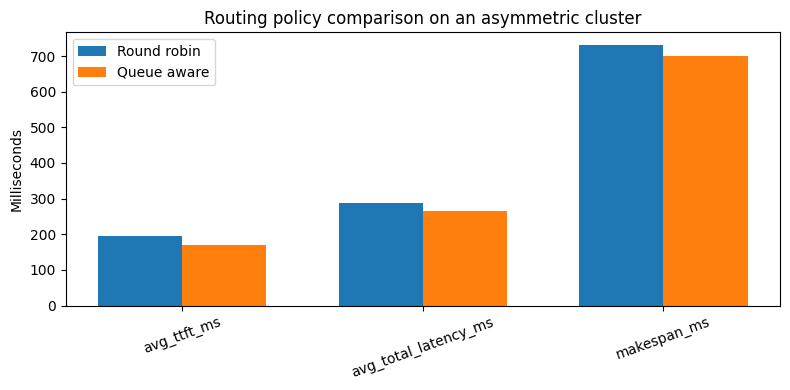

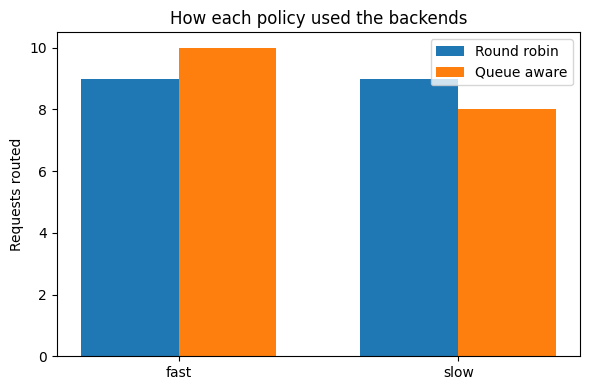

In [6]:

# ============================================================
# Queue-aware routing demo
# ============================================================

routing_requests = make_bursty_routing_workload(seed=11, num_requests=18)

# We intentionally make one backend faster and one slower so the
# routing decision matters.
fast_backend_config = EngineConfig(
    step_ms=10,
    token_budget_per_step=16,
    max_prefill_chunk_per_request=8,
    enable_prefix_cache=False,
)
slow_backend_config = EngineConfig(
    step_ms=10,
    token_budget_per_step=4,
    max_prefill_chunk_per_request=8,
    enable_prefix_cache=False,
)

# ----- Round robin -----
rr_cluster = ClusterRouterSimulator(
    backends=[
        ContinuousBatchingSimulator(fast_backend_config, name="fast"),
        ContinuousBatchingSimulator(slow_backend_config, name="slow"),
    ],
    policy="round_robin",
)
rr_completed, rr_history = rr_cluster.run(routing_requests)
rr_summary = summarize_cluster_run(rr_completed, rr_history, rr_cluster.backends)

# ----- Queue aware -----
qa_cluster = ClusterRouterSimulator(
    backends=[
        ContinuousBatchingSimulator(fast_backend_config, name="fast"),
        ContinuousBatchingSimulator(slow_backend_config, name="slow"),
    ],
    policy="queue_aware",
)
qa_completed, qa_history = qa_cluster.run(routing_requests)
qa_summary = summarize_cluster_run(qa_completed, qa_history, qa_cluster.backends)

print("Round-robin summary")
for key in ["avg_ttft_ms", "p95_ttft_ms", "avg_total_latency_ms", "p95_total_latency_ms", "makespan_ms", "prompt_tokens_per_s", "output_tokens_per_s"]:
    print(f"  {key:>22}: {rr_summary[key]:.2f}")
print("  route_counts:", rr_summary["route_counts"])

print("\nQueue-aware summary")
for key in ["avg_ttft_ms", "p95_ttft_ms", "avg_total_latency_ms", "p95_total_latency_ms", "makespan_ms", "prompt_tokens_per_s", "output_tokens_per_s"]:
    print(f"  {key:>22}: {qa_summary[key]:.2f}")
print("  route_counts:", qa_summary["route_counts"])

# Compare a few headline metrics.
metric_names = ["avg_ttft_ms", "avg_total_latency_ms", "makespan_ms"]
rr_values = [rr_summary[name] for name in metric_names]
qa_values = [qa_summary[name] for name in metric_names]

x_positions = range(len(metric_names))
bar_width = 0.35

plt.figure(figsize=(8, 4))
plt.bar([x - bar_width / 2 for x in x_positions], rr_values, width=bar_width, label="Round robin")
plt.bar([x + bar_width / 2 for x in x_positions], qa_values, width=bar_width, label="Queue aware")
plt.xticks(list(x_positions), metric_names, rotation=20)
plt.ylabel("Milliseconds")
plt.title("Routing policy comparison on an asymmetric cluster")
plt.legend()
plt.tight_layout()
plt.show()

# Plot route-count comparison.
labels = ["fast", "slow"]
rr_counts = [rr_summary["route_counts"].get(label, 0) for label in labels]
qa_counts = [qa_summary["route_counts"].get(label, 0) for label in labels]

x_positions = range(len(labels))

plt.figure(figsize=(6, 4))
plt.bar([x - bar_width / 2 for x in x_positions], rr_counts, width=bar_width, label="Round robin")
plt.bar([x + bar_width / 2 for x in x_positions], qa_counts, width=bar_width, label="Queue aware")
plt.xticks(list(x_positions), labels)
plt.ylabel("Requests routed")
plt.title("How each policy used the backends")
plt.legend()
plt.tight_layout()
plt.show()



### What to notice

In an asymmetric cluster:
- round robin can keep sending work to a slow backend even when it is already backed up
- queue-aware routing can shift more traffic toward the backend with lower current pressure

That does not mean queue-aware routing is always best.
Real systems may also consider:
- request size
- health state
- cache locality
- backend model version
- fairness / tenant isolation



## 6. Server observability

One of the most practical interview skills is knowing **what to measure**.

A good inference system typically wants observability for:
- waiting requests
- running / decoding requests
- queue depth
- prompt token throughput
- generation token throughput
- queue time
- TTFT / total latency distributions
- prefix-cache hit rate
- route decisions and fallback reasons

Below we export a tiny Prometheus-style text snapshot from the simulator and then parse it back.


Tiny /metrics-style snapshot
inference_waiting_requests 0.0
inference_decoding_requests 0.0
inference_queue_depth 0.0
inference_prompt_tokens_total 176
inference_output_tokens_total 80
inference_prefix_cache_hit_rate 0.700000
inference_cache_entries 2.0

Parsed back into a dictionary
        inference_waiting_requests: 0.0000
       inference_decoding_requests: 0.0000
             inference_queue_depth: 0.0000
     inference_prompt_tokens_total: 176.0000
     inference_output_tokens_total: 80.0000
   inference_prefix_cache_hit_rate: 0.7000
           inference_cache_entries: 2.0000


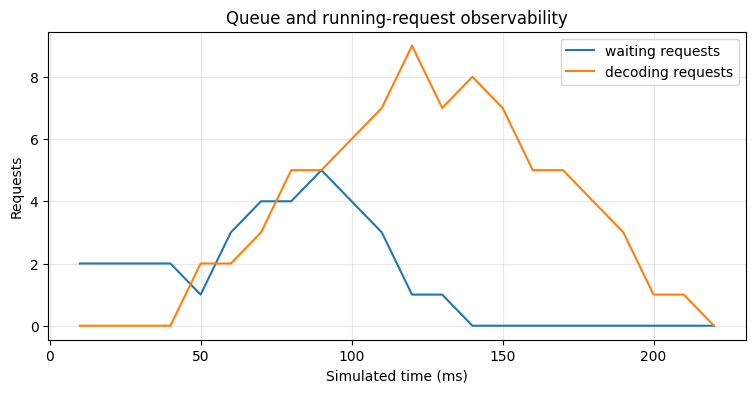

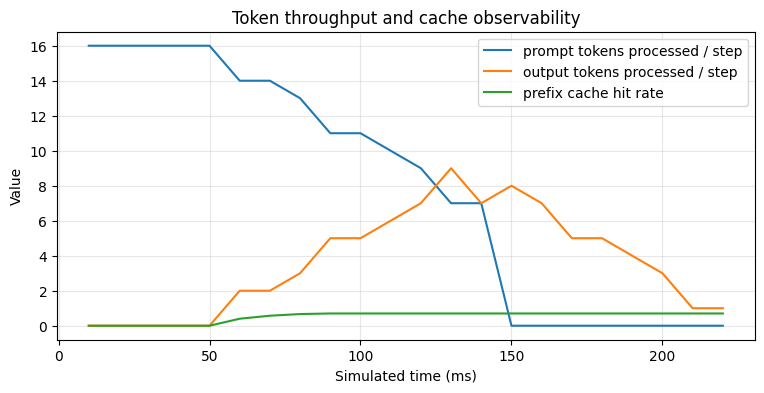

In [7]:

# ============================================================
# Observability demo
# ============================================================

# Reuse the cache-enabled backend from the prefix-cache section.
metrics_text = export_metrics_text(cache_server)
metrics_dict = parse_metrics_text(metrics_text)

print("Tiny /metrics-style snapshot")
print(metrics_text)

print("\nParsed back into a dictionary")
for key, value in metrics_dict.items():
    print(f"  {key:>32}: {value:.4f}")

# Plot a few time-series from the cache-enabled run.
times = [entry["time_ms"] for entry in cache_history]
waiting_series = [entry["waiting_requests"] for entry in cache_history]
decoding_series = [entry["decoding_requests"] for entry in cache_history]
prompt_series = [entry["prompt_tokens_processed"] for entry in cache_history]
decode_series = [entry["output_tokens_processed"] for entry in cache_history]
cache_hit_series = [entry["prefix_cache_hit_rate"] for entry in cache_history]

plt.figure(figsize=(9, 4))
plt.plot(times, waiting_series, label="waiting requests")
plt.plot(times, decoding_series, label="decoding requests")
plt.xlabel("Simulated time (ms)")
plt.ylabel("Requests")
plt.title("Queue and running-request observability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(times, prompt_series, label="prompt tokens processed / step")
plt.plot(times, decode_series, label="output tokens processed / step")
plt.plot(times, cache_hit_series, label="prefix cache hit rate")
plt.xlabel("Simulated time (ms)")
plt.ylabel("Value")
plt.title("Token throughput and cache observability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



## 7. Key interview takeaways

A clean way to explain the major ideas is:

### Prefill vs decode
- **Prefill** ingests the prompt and often dominates TTFT for long prompts.
- **Decode** produces output tokens and determines streaming speed after the first token.

### Continuous batching
- improves utilization by overlapping work across requests
- often helps throughput and makespan
- creates scheduling tradeoffs between fairness and responsiveness

### Queue-aware routing
- uses current backend pressure to make better routing choices
- becomes more useful when backends are uneven or bursty

### Prefix caching
- reduces repeated prompt computation for shared prefixes
- helps prefill-heavy workloads
- trades compute savings against cache-memory usage and cache management complexity

### Observability
- if you cannot see queue depth, running requests, token throughput, and cache hit rate, you are operating partially blind



## 8. Interview-style exercises

### Exercise 1 — Why is TTFT often strongly affected by prompt length?

**Hint:**  
Think about which phase has to happen before the first output token can appear.



### Exercise 1 — Answer

TTFT includes:
- queueing delay
- prefill work
- the first decode step

Longer prompts usually increase prefill work, so TTFT often grows with prompt length even if decode speed stays the same.



### Exercise 2 — Why can continuous batching improve throughput but still hurt some tail latencies?

**Hint:**  
Think about resource sharing and fairness.



### Exercise 2 — Answer

Continuous batching improves throughput because it keeps the device busy across many requests.

But when many requests compete for the same token budget:
- some requests can wait longer
- large prompts can still create pressure
- fairness and priority policy matter

So average throughput can improve while some tail requests still get worse.



### Exercise 3 — Why does prefix caching reduce prefill work without changing model outputs?

**Hint:**  
Ask yourself what is being reused.



### Exercise 3 — Answer

Prefix caching reuses already-computed prompt-side state for a shared prefix.

It does not change the prompt or the model.
It just avoids recomputing the same prefix work again.

So the semantics stay the same, but the compute cost changes.



### Exercise 4 — When is round robin more likely to be good enough, and when is queue-aware routing more valuable?

**Hint:**  
Think about backend symmetry and queue imbalance.



### Exercise 4 — Answer

Round robin is often good enough when:
- backends are similar
- health is stable
- load is fairly even

Queue-aware routing becomes more valuable when:
- one backend is slower
- one backend is already backed up
- arrivals are bursty and uneven
- queue state changes quickly



### Exercise 5 — If users say "responses start slowly," which metrics would you inspect first?

**Hint:**  
Think about the metrics most connected to first-token delay.



### Exercise 5 — Answer

A good first set would be:
- queue depth / waiting requests
- queue time
- TTFT
- prompt token throughput
- prompt lengths
- prefix-cache hit rate if prefix caching is enabled

These are the metrics most directly connected to "slow start" complaints.



### Exercise 6 — Small coding challenge

Modify the scheduler so a single request can use a larger prefill chunk per step.

What do you expect to happen to:
- fairness
- TTFT for that request
- tail behavior for other waiting requests?

**Hint:**  
Look for `max_prefill_chunk_per_request` in the simulator config.



### Exercise 6 — Answer

If one request is allowed to consume larger prefill chunks per step:
- that request may get a better TTFT
- fairness can get worse
- other waiting requests may wait longer
- tail latency can become worse even if one large prompt improves

This is exactly the kind of scheduler tradeoff interviewers like to discuss.



## 9. Final advice for interviews

If you can explain the following clearly, you are in strong shape for inference-systems interviews:

1. the difference between **prefill** and **decode**  
2. why **TTFT** is often prefill-sensitive  
3. how **continuous batching** changes throughput and latency  
4. when **queue-aware routing** helps more than round robin  
5. why **prefix caching** helps some workloads more than others  
6. which metrics belong on a **/metrics** endpoint  

That combination is very useful for:
- serving-platform interviews
- runtime / scheduler interviews
- LLM infrastructure interviews



## 10. Suggested next steps

After this notebook, a good next progression is:

1. add request-size-aware routing  
2. add a "fast" and "slow" prompt class and compare scheduler behavior  
3. add a fallback backend and track fallback reasons  
4. add a simple cache-capacity limit with eviction  
5. read real serving-system docs and map their metrics to the ideas here  

The goal is not just to memorize terms.
The goal is to build a clear mental model of what an inference system is doing and why.


## 11. Production-inspired interview Q&A (basic serving focus)

This section adds **10 scenario-based interview questions** in the style of real LLM inference / serving interviews.

These are intentionally focused on the same core ideas already covered in this notebook:
- TTFT and prompt-side pressure
- queueing and fairness
- continuous batching tradeoffs
- prefix caching
- queue-aware routing
- observability
- overload behavior

Use them like this:
1. read only the **question**
2. say your answer out loud in 30–90 seconds
3. compare yourself against the **weak answer**
4. then compare yourself against the **strong answer**
5. finally read **why this is strong** and see whether you explained the system tradeoff clearly

The goal is not to memorize exact wording.
The goal is to practice the habit of:
- identifying the likely bottleneck first
- naming the right metrics
- separating average behavior from tail behavior
- explaining user impact, not just kernel speed

### Q1: "Our TTFT doubled after onboarding a new retrieval-heavy workload. Tokens/sec stayed roughly flat. What do you suspect first?"

**Weak answer:**  
"Attention got slower."

**Strong answer:**  
"I would first suspect prompt-side pressure rather than decode-side pressure. Retrieval-heavy traffic usually increases prompt length and prompt variance, so TTFT can rise even if steady-state decode throughput looks similar. I would check prompt length distribution, queueing time, prefill share of work, and whether a few long prompts are crowding out short interactive requests. Then I would look for shared-prefix opportunities and request-shaping rules for very large prompts."

**Why this is strong:**  
It separates **TTFT** from overall tokens/sec and starts from the most likely workload change.

### Q2: "Router CPU is pegged, GPU utilization is low, and users say responses start slowly. What does that tell you?"

**Weak answer:**  
"The GPUs are too slow."

**Strong answer:**  
"It suggests the GPUs are being underfed. I would inspect tokenization, request validation, JSON/tool shaping, routing logic, batching-loop behavior, and any proxy or front-end bottlenecks before touching GPU kernels. If the front-end cannot prepare and feed requests fast enough, TTFT can be bad even while the GPUs are mostly idle."

**Why this is strong:**  
It shows end-to-end systems thinking instead of assuming the accelerator is always the bottleneck.

### Q3: "After enabling continuous batching, throughput improved a lot, but some users say the service feels slower. How can both be true?"

**Weak answer:**  
"That should not happen if batching is working."

**Strong answer:**  
"Continuous batching can improve average throughput while still hurting some individual requests. If the scheduler is tuned mainly for utilization, some short requests may wait behind long prompts or busy decode streams. So I would compare average latency against p95/p99 latency, look at queueing by request size, and check whether fairness or priority policy needs to change."

**Why this is strong:**  
It recognizes the difference between **system efficiency** and **per-request experience**.

### Q4: "Our prefix-cache hit rate is low even though many users share the same system prompt. Why might that happen?"

**Weak answer:**  
"The cache layer is broken."

**Strong answer:**  
"It could be a bug, but I would first verify token-level identity. Small changes in whitespace, timestamps, request metadata, retrieval ordering, or even tokenizer version can turn visually similar prompts into different token sequences. I would inspect the exact tokenized prefix and normalize prompt construction before blaming the cache runtime."

**Why this is strong:**  
It shows you understand that prefix reuse depends on **exact token identity**, not visual similarity.

### Q5: "Two backends have the same GPU type and the same model, but one consistently shows worse TTFT. What would you compare first?"

**Weak answer:**  
"Maybe that GPU is defective."

**Strong answer:**  
"I would first compare queue depth, in-flight request count, prompt-length mix, front-end CPU pressure, and routing share before assuming the hardware is the problem. In serving systems, two identical GPUs can behave very differently if one is getting longer prompts, more concurrent work, or slower request preparation upstream."

**Why this is strong:**  
It focuses on **workload shape and queue pressure** before jumping to hardware conclusions.

### Q6: "Users say: \"responses start slowly.\" Which metrics would you inspect first?"

**Weak answer:**  
"Overall tokens/sec."

**Strong answer:**  
"I would start with waiting-request count, queue time, TTFT, prompt length distribution, prompt-side throughput, and prefix-cache hit rate if caching is enabled. Those metrics are closest to first-token delay. Tokens/sec matters too, but it is often not the first metric to explain why responses feel slow to start."

**Why this is strong:**  
It connects the complaint to the metrics most directly tied to **first-token responsiveness**.

### Q7: "When is round robin good enough, and when is queue-aware routing clearly better?"

**Weak answer:**  
"Queue-aware routing is always better."

**Strong answer:**  
"Round robin is often fine when backends are similar, health is stable, and load is fairly even. Queue-aware routing becomes much more valuable when one backend is slower, one queue is already backed up, or arrivals are bursty and uneven. The choice depends on how much backend pressure changes over time and whether routing decisions can react fast enough to matter."

**Why this is strong:**  
It shows balanced engineering judgment rather than treating one policy as universally correct.

### Q8: "Under overload, should we keep accepting requests and let them queue?"

**Weak answer:**  
"Yes, because rejecting requests is always worse."

**Strong answer:**  
"Not blindly. If the queue keeps growing, admitted requests may miss the product SLO anyway. I would rather protect admitted latency with queue caps, traffic classes, tighter max-output policies, or early rejection than silently degrade the whole service. The goal is to preserve a predictable experience for interactive traffic instead of making everyone wait."

**Why this is strong:**  
It shows maturity around **SLO protection** and graceful degradation.

### Q9: "Average latency stayed about the same, but p99 got much worse after we added more long prompts. What is your first read?"

**Weak answer:**  
"The average says the system is fine."

**Strong answer:**  
"My first read is that long prompts are creating tail interference rather than shifting the whole average. Averages can hide the fact that a smaller set of requests is waiting much longer because long prompt-prefill work or larger queues are creating head-of-line pressure. I would inspect latency by request size, queueing distribution, and prompt-length percentiles rather than relying on the mean."

**Why this is strong:**  
It shows you know how **tail behavior** can diverge from averages in shared serving systems.

### Q10: "One very long prompt arrives and suddenly many short chat requests slow down. What kinds of policies would you consider?"

**Weak answer:**  
"Just let the long request finish because fairness means first come, first served."

**Strong answer:**  
"I would consider request-size-aware scheduling, per-request prompt caps, separate interactive vs long-job lanes, or other fairness controls that stop one large request from dominating shared capacity. The right answer depends on product goals, but I would explicitly protect short interactive traffic instead of assuming a single global queue is always correct."

**Why this is strong:**  
It shows you can translate scheduler behavior into **product-aware serving policy**.